
# LLM Comprehensive Evaluation Notebook

This notebook evaluates all key metrics for our LLM checkpoints:

- **Parameter Count:** Total number of parameters in millions.
- **Perplexity:** Measured on a small subset of WikiText‑2 (a proxy for language modeling accuracy).
- **Generation Quality:** Using BLEU and ROUGE scores on a set of context‑specific evaluation prompts
  (which include question answering, relevance, and hallucination detection).
- **Toxicity:** Average toxicity score computed over generated texts.

The checkpoints evaluated are:
- **Initial:** `../checkpoints`
- **Quantized:** `../checkpoints/model_quantized`
- **LoRA Finetuned:** `../checkpoints/model_lora`
- **Pruned:** `../checkpoints/model_pruned`

All models are loaded in float16 (or equivalent mixed precision where applicable) and on the appropriate device.

**Note:** You may need to install the `evaluate` library (`pip install evaluate`) and ensure you have internet
access for downloading reference metric models. The toxicity evaluation uses a pretrained pipeline model.


In [3]:

import os
import time
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed, pipeline
from datasets import load_from_disk

# For evaluation metrics; ensure you have installed the evaluate package: pip install evaluate
import evaluate

# Disable parallelism for tokenizers to avoid fork warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Set seed for reproducibility
set_seed(42)

# Define checkpoint directories
checkpoint_dirs = {
    "Initial": "../checkpoints",
    "Quantized": "../checkpoints/model_quantized",
    "LoRA Finetuned": "../checkpoints/model_lora",
    "Pruned": "../checkpoints/model_pruned"
}

def get_device():
    """Select device: Prefer MPS (Apple Silicon) > CUDA > CPU"""
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Device Selected: MPS (Apple Silicon)")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("Device Selected: CUDA")
    else:
        device = torch.device("cpu")
        print("Device Selected: CPU")
    return device

device = get_device()

def get_folder_size(directory):
    """Return total folder size in MB."""
    total_size = 0
    for dirpath, _, filenames in os.walk(directory):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return total_size / (1024 * 1024)

# Initialize evaluation metrics using the evaluate library
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
    
# Initialize toxicity detector pipeline (if available)
try:
    toxicity_detector = pipeline("text-classification", model="unitary/toxic-bert", device=0 if device.type=="cuda" else -1)
except Exception as e:
    print("Toxicity detector pipeline not available, using dummy toxicity evaluation.")
    toxicity_detector = None


Device Selected: MPS (Apple Silicon)


config.json:   0%|          | 0.00/811 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


## Evaluation Dataset for Generation Quality & QA Accuracy

We define a small set of evaluation samples. Each sample includes:
- A prompt (which can be a question or request for a short explanation).
- A reference output that represents a desirable answer.

These samples are used to compute BLEU and ROUGE scores.

In [4]:
evaluation_samples = [
    {
        "prompt": "What is the capital of France?",
        "reference": "The capital of France is Paris."
    },
    {
        "prompt": "Who wrote 'Pride and Prejudice'?",
        "reference": "Jane Austen wrote Pride and Prejudice."
    },
    {
        "prompt": "Explain the process of photosynthesis briefly.",
        "reference": "Photosynthesis is the process by which plants convert sunlight, water, and carbon dioxide into oxygen and energy."
    }
]


## Functions for Metric Evaluations

We define several helper functions:

1. **compute_perplexity:** Evaluates the model’s perplexity on a few examples from WikiText‑2.
2. **evaluate_generation_metrics:** Generates texts from prompts and computes BLEU and ROUGE scores.
3. **evaluate_toxicity:** Uses a toxicity detector to compute an average toxicity score.
4. **get_parameter_count:** Returns total number of parameters in millions.

In [8]:
# %% [code]
def compute_perplexity(model, tokenizer, dataset, num_examples=10, max_length=128):
    """
    Compute perplexity on a subset of the dataset by feeding tokenized text and computing loss.
    Returns the exponential of the average loss.
    """
    model.eval()
    losses = []
    count = 0
    for example in dataset:
        text = example.get("text", "").strip()
        if not text:
            continue
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs, labels=inputs["input_ids"])
        loss = outputs.loss.item()
        losses.append(loss)
        count += 1
        if count >= num_examples:
            break
    if losses:
        avg_loss = np.mean(losses)
        perplexity = np.exp(avg_loss)
        return perplexity
    return None

def evaluate_generation_metrics(model, tokenizer, samples, max_new_tokens=50):
    """
    Generate outputs for each sample prompt and compute BLEU and ROUGE scores.
    Returns:
      - bleu_score: BLEU metric score.
      - rouge1_f: ROUGE-1 F1 score.
      - generated_texts: List of generated completions.
      - references: List of reference texts.
    """
    generated_texts = []
    references = []
    for sample in samples:
        inputs = tokenizer(sample["prompt"], return_tensors="pt", truncation=True, max_length=128).to(device)
        generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
        output_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
        generated_texts.append(output_text)
        references.append(sample["reference"])
    # Compute BLEU
    bleu_score = bleu_metric.compute(predictions=generated_texts, references=[[ref] for ref in references])["bleu"]
    # Compute ROUGE and extract rouge1
    rouge_score = rouge_metric.compute(predictions=generated_texts, references=references)
    # Check if the result is a dict with an "fmeasure" field; if not, use the value directly.
    if isinstance(rouge_score["rouge1"], dict):
        rouge1_f = rouge_score["rouge1"].get("fmeasure", None)
    else:
        rouge1_f = rouge_score["rouge1"]
    return bleu_score, rouge1_f, generated_texts, references


def evaluate_toxicity(generated_texts):
    """
    Compute the average toxicity score for a list of generated texts.
    If a toxicity detector is not available, return 0.
    """
    if toxicity_detector is None:
        return 0.0
    scores = []
    for text in generated_texts:
        try:
            outputs = toxicity_detector(text)
            # Assume the first output's score indicates toxicity probability if label contains "TOXIC"
            if outputs[0]["label"].upper() == "TOXIC":
                scores.append(outputs[0]["score"])
            else:
                scores.append(0.0)
        except Exception as e:
            scores.append(0.0)
    return np.mean(scores)

def get_parameter_count(model):
    """Return total number of parameters in millions."""
    return model.num_parameters() / 1e6


## 5. Load WikiText‑2 Evaluation Subset

We load a subset of the WikiText‑2 dataset (from `../data/wikitext-2`) to compute perplexity.

In [6]:
# Load dataset from disk; using "train" split for evaluation purposes (filtering empty examples)
DATASET_DIR = "../data/wikitext-2"
dataset_full = load_from_disk(DATASET_DIR)
eval_dataset = dataset_full["train"].filter(lambda x: len(x["text"].strip()) > 0)
print(f"Evaluating perplexity on {min(10, len(eval_dataset))} examples out of {len(eval_dataset)} total.")

Evaluating perplexity on 10 examples out of 23767 total.


## 6. Evaluate All Checkpoints

For each checkpoint we:
- Load the model and tokenizer (in float16 and on the selected device).
- Compute:
  - Parameter count.
  - Perplexity on a small WikiText‑2 subset.
  - Generation quality (BLEU and ROUGE scores) on our evaluation prompts.
  - Average toxicity score on the generated texts.

The results for each checkpoint are stored in a dictionary.

In [9]:
# %% [code]
evaluation_results = {}

for stage, ckpt_path in checkpoint_dirs.items():
    print(f"\nEvaluating checkpoint: {stage}")
    try:
        # Load model and tokenizer
        model = AutoModelForCausalLM.from_pretrained(
            ckpt_path,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True
        )
        tokenizer = AutoTokenizer.from_pretrained(ckpt_path)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        model.to(device)
    except Exception as e:
        print(f"Error loading model from {ckpt_path}: {e}")
        continue

    # Compute parameter count
    param_count = get_parameter_count(model)
    
    # Compute perplexity on a few examples
    perplexity = compute_perplexity(model, tokenizer, eval_dataset, num_examples=10)
    
    # Evaluate generation quality on our evaluation samples
    bleu, rouge1, generated_texts, refs = evaluate_generation_metrics(model, tokenizer, evaluation_samples)
    
    # Evaluate toxicity score on the generated outputs
    toxicity = evaluate_toxicity(generated_texts)
    
    evaluation_results[stage] = {
        "parameter_count_million": param_count,
        "perplexity": perplexity,
        "bleu": bleu,
        "rouge1_f": rouge1,
        "toxicity": toxicity,
        "generated_texts": generated_texts,
        "references": refs
    }
    
    print(f"{stage} - Params: {param_count:.2f}M, Perplexity: {perplexity:.2f}, BLEU: {bleu:.3f}, ROUGE-1 F: {rouge1:.3f}, Toxicity: {toxicity:.3f}")

# Save the evaluation results for further reference
output_evaluation_file = "../checkpoints/analysis/evaluation_results.json"
os.makedirs(os.path.dirname(output_evaluation_file), exist_ok=True)
with open(output_evaluation_file, "w") as f:
    json.dump(evaluation_results, f, indent=4)
print(f"\nEvaluation metrics saved to {output_evaluation_file}")



Evaluating checkpoint: Initial


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Initial - Params: 124.44M, Perplexity: 155.44, BLEU: 0.049, ROUGE-1 F: 0.184, Toxicity: 0.001

Evaluating checkpoint: Quantized


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing GPT2LMHeadModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Quantized - Params: 124.44M, Perplexity: 155.44, BLEU: 0.049, ROUGE-1 F: 0.184, Toxicity: 0.001

Evaluating checkpoint: LoRA Finetuned
'NoneType' object has no attribute 'cadam32bit_grad_fp32'


/Users/swayamsingal/miniconda3/envs/research_env/lib/python3.10/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Some weights of the model checkpoint at ../checkpoints/model_quantized were not used when initializing GPT2LMHeadModel: ['lm_head.scale', 'lm_head.zero_point']
- This IS expected if you are initializing GPT2LMHeadModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are in

LoRA Finetuned - Params: 124.73M, Perplexity: 903.26, BLEU: 0.000, ROUGE-1 F: 0.607, Toxicity: 0.001

Evaluating checkpoint: Pruned


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Pruned - Params: 124.73M, Perplexity: 155.44, BLEU: 0.049, ROUGE-1 F: 0.184, Toxicity: 0.001

Evaluation metrics saved to ../checkpoints/analysis/evaluation_results.json


## 7. Visualize Key Metrics

We then create a bar chart comparing parameter count, perplexity, BLEU, ROUGE‑1 F1, and toxicity across checkpoints.

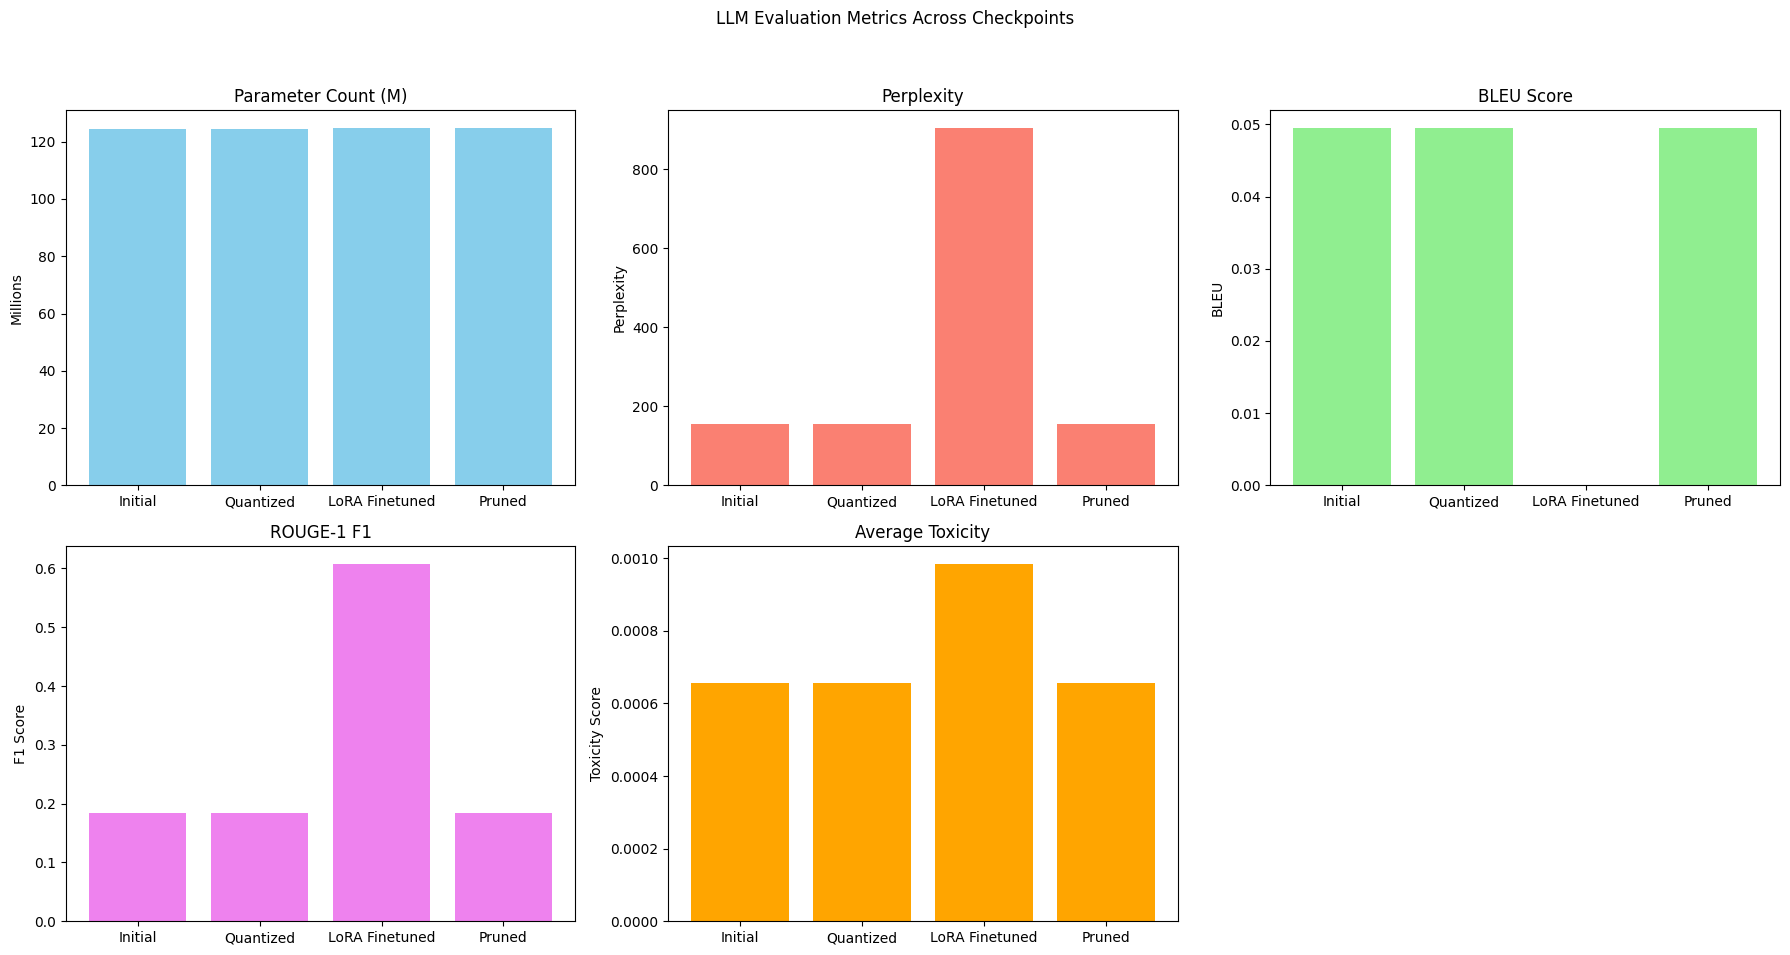

In [10]:
# %% [code]
stages = list(evaluation_results.keys())

# Gather each metric for visualization
param_counts = [evaluation_results[stage]["parameter_count_million"] for stage in stages]
perplexities = [evaluation_results[stage]["perplexity"] for stage in stages]
bleu_scores = [evaluation_results[stage]["bleu"] for stage in stages]
rouge_scores = [evaluation_results[stage]["rouge1_f"] for stage in stages]
toxicity_scores = [evaluation_results[stage]["toxicity"] for stage in stages]

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

axs[0].bar(stages, param_counts, color="skyblue")
axs[0].set_title("Parameter Count (M)")
axs[0].set_ylabel("Millions")

axs[1].bar(stages, perplexities, color="salmon")
axs[1].set_title("Perplexity")
axs[1].set_ylabel("Perplexity")

axs[2].bar(stages, bleu_scores, color="lightgreen")
axs[2].set_title("BLEU Score")
axs[2].set_ylabel("BLEU")

axs[3].bar(stages, rouge_scores, color="violet")
axs[3].set_title("ROUGE-1 F1")
axs[3].set_ylabel("F1 Score")

axs[4].bar(stages, toxicity_scores, color="orange")
axs[4].set_title("Average Toxicity")
axs[4].set_ylabel("Toxicity Score")

# Hide the unused subplot if any
axs[5].axis("off")

plt.suptitle("LLM Evaluation Metrics Across Checkpoints")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Completion Message

The notebook has:
- Loaded each checkpoint model.
- Computed key evaluation metrics (parameter count, perplexity, BLEU, ROUGE, toxicity).
- Saved the results to a JSON file.
- Visualized the metrics for cross-checking.

This comprehensive evaluation helps you assess the trade-offs in performance and quality across your pipeline.

In [11]:
print("LLM comprehensive evaluation complete.")

LLM comprehensive evaluation complete.
